---
## Section 0 — Imports and Database Connection

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
import sqlalchemy
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import mysql.connector

# Modelling
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')


# Path().resolve() finds the notebook's actual location on disk regardless
# of how VS Code launched it. .parent moves one level up to the project root.
PROJECT_ROOT = Path().resolve().parent
REPORTS_DIR  = PROJECT_ROOT / 'reports'
ENV_FILE     = PROJECT_ROOT / '.env'

load_dotenv(ENV_FILE)

print('Imports complete.')
print(f'Project root : {PROJECT_ROOT}')
print(f'Reports dir  : {REPORTS_DIR}')

Imports complete.
Project root : /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Github refurb/nashville analytics
Reports dir  : /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Github refurb/nashville analytics/reports


In [ ]:
def get_connection():
    """Raw MySQL connection for inserts."""
    return mysql.connector.connect(
        host=os.getenv('DB_HOST'),
        user=os.getenv('DB_USER'),
        password=os.getenv('DB_PASSWORD'),
        database=os.getenv('DB_NAME')
    )



def get_engine():
    """SQLAlchemy engine for pandas read_sql."""
    password = quote_plus(os.getenv('DB_PASSWORD')) # pyright: ignore[reportArgumentType, reportCallIssue]
    return create_engine(
        f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{password}"
        f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
    )

# Test connection

try:
    conn = get_connection()
    print(f"Connected to MySQL database: {os.getenv('DB_NAME')}")
    conn.close()
except Exception as e:
    print(f"Connection failed: {e}")


Connected to MySQL database: nashville_analytics


---
## Section 1 — Load and Prepare the Modelling Dataset

We load only records where every input feature is non-null. This is the complete-records scope discussed in the objective above.

We also consolidate the two vacant residential land labels (`VACANT RES LAND` and `VACANT RESIDENTIAL LAND`) here. These are the same asset type with inconsistent labelling — the label changed mid-dataset. Keeping them separate would create a phantom difference in any model that encodes land use as a feature.

In [5]:
# Load data and compute CPI-adjusted price
# sale_price_real is recomputed here from the BLS API rather than loaded
# from a processed file. This makes Notebook 03 self-contained — it does
# not depend on Notebook 02 having been run first.

import requests

BLS_API_KEY = os.getenv('BLS_API_KEY')

BLS_URL = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

payload = {
    "seriesid": ["CUUR0000SA0"],
    "startyear": "2013",
    "endyear": "2016",
    "annualaverage": True,
    "registrationkey": BLS_API_KEY
}

response = requests.post(BLS_URL, json=payload)
response.raise_for_status()

bls_data = response.json()

if bls_data["status"] != "REQUEST_SUCCEEDED":
    raise ValueError(f"BLS API request failed: {bls_data['message']}")

series_data = bls_data["Results"]["series"][0]["data"]

# M13 is the BLS code for the annual average period
annual_cpi = {
    int(row["year"]): float(row["value"])
    for row in series_data
    if row["period"] == "M13"
}

cpi_base = annual_cpi[2013]
print(f"CPI base (2013): {cpi_base}")
print(f"CPI lookup: {annual_cpi}")

CPI base (2013): 232.957
CPI lookup: {2016: 240.007, 2015: 237.017, 2014: 236.736, 2013: 232.957}


In [6]:
query = """
SELECT
    parcel_id,
    sale_price,
    YEAR(sale_date) AS sale_year,
    land_use,
    tax_district,
    land_value,
    building_value,
    acreage,
    finished_area,
    year_built,
    bedrooms,
    full_bath,
    half_bath,
    sold_as_vacant,
    price_outlier_flag
FROM nashville_housing_clean
WHERE
    land_value          IS NOT NULL
    AND building_value  IS NOT NULL
    AND acreage         IS NOT NULL
    AND finished_area   IS NOT NULL
    AND year_built      IS NOT NULL
    AND bedrooms        IS NOT NULL
    AND full_bath       IS NOT NULL
    AND half_bath       IS NOT NULL
    AND sale_price      > 0
    AND price_outlier_flag = 'CLEAN'
"""

engine = get_engine()
try:
    df_raw = pd.read_sql(query, engine)
finally:
    engine.dispose()

df = df_raw.copy()

# Consolidate the two vacant residential land labels
df['land_use'] = df['land_use'].replace('VACANT RES LAND', 'VACANT RESIDENTIAL LAND')

# Compute CPI-adjusted price — same method as Notebook 02
df['cpi_sale_year'] = df['sale_year'].map(annual_cpi)
df['sale_price_real'] = df['sale_price'] * (cpi_base / df['cpi_sale_year'])

# Property age is more interpretable than year_built as a model feature
df['age_at_sale'] = df['sale_year'] - df['year_built']
df['age_at_sale'] = df['age_at_sale'].clip(lower=0, upper=150)

print(f"Full clean table rows : 56,468")
print(f"Complete-records rows : {len(df):,}")
print(f"Coverage              : {len(df) / 56468:.1%}")

Full clean table rows : 56,468
Complete-records rows : 23,157
Coverage              : 41.0%


In [7]:

# Consolidate the two vacant residential land labels.
# 'VACANT RES LAND' appears only in 2013 and refers to the same asset type
# as 'VACANT RESIDENTIAL LAND'. Treating them as different categories would
# create a spurious feature difference in the model.
df['land_use'] = df['land_use'].replace('VACANT RES LAND', 'VACANT RESIDENTIAL LAND')

# Property age is more interpretable than year built for a model:
# a coefficient on age_at_sale has a direct meaning (price change per extra year of age),
# whereas a coefficient on year_built is harder to interpret because the reference
# point (year 0) is meaningless.
df['age_at_sale'] = df['sale_year'] - df['year_built']

# Clamp implausible ages. A handful of records have year_built values that produce
# ages over 200 years — likely data entry errors. We cap at 150 to keep them
# in the dataset without letting them distort the model.
df['age_at_sale'] = df['age_at_sale'].clip(lower=0, upper=150)

print(f'Full clean table rows : {56468:,}')
print(f'Complete-records rows : {len(df):,}')
print(f'Coverage              : {len(df) / 56468:.1%}')
print()
print('Land use value counts (top 10):')
print(df['land_use'].value_counts().head(10))

Full clean table rows : 56,468
Complete-records rows : 23,157
Coverage              : 41.0%

Land use value counts (top 10):
land_use
SINGLE FAMILY               20475
DUPLEX                       1167
ZERO LOT LINE                 842
VACANT RESIDENTIAL LAND       462
TRIPLEX                        76
RESIDENTIAL COMBO/MISC         34
QUADPLEX                       34
CHURCH                         19
DORMITORY/BOARDING HOUSE       14
SPLIT CLASS                     9
Name: count, dtype: int64


---
## Section 2 — Feature Engineering

We need to convert categorical columns (`land_use`, `tax_district`, `sold_as_vacant`) into numbers before feeding them into the model. The method used here is **one-hot encoding**: each category becomes its own binary column (1 if the property belongs to that category, 0 otherwise).

We drop one category per variable to avoid the **dummy variable trap**: if you encode all categories, one column is perfectly predictable from the others, which creates a collinearity problem. Dropping one (the baseline) means every coefficient is interpreted as the effect *relative to that baseline*.

The target variable is `sale_price_real_2013` rather than raw `sale_price`. Using CPI-adjusted prices means the model is learning the relationship between property characteristics and real purchasing power, not nominal prices that changed partly due to inflation.

In [9]:
# Feature definitions
TARGET = 'sale_price_real'

NUMERIC_FEATURES = [
    'land_value',
    'building_value',
    'acreage',
    'finished_area',
    'age_at_sale',
    'bedrooms',
    'full_bath',
    'half_bath',
    'sale_year',
]

CATEGORICAL_FEATURES = ['land_use', 'tax_district', 'sold_as_vacant']

# One-hot encode categorical features
df_encoded = pd.get_dummies(
    df[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, 'parcel_id']],
    columns=CATEGORICAL_FEATURES,
    drop_first=True,    # Drop one category per variable to avoid dummy variable trap
    dtype=float
)

# Target and feature matrices
FEATURE_COLS = [c for c in df_encoded.columns if c not in [TARGET, 'parcel_id']]

X = df_encoded[FEATURE_COLS]
y = df_encoded[TARGET]
ids = df_encoded['parcel_id']   # Retained for residual mapping later

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Number of features   : {X.shape[1]}')
print()
print('First five feature names:')
print(FEATURE_COLS[:5])

Feature matrix shape : (23157, 38)
Target vector shape  : (23157,)
Number of features   : 38

First five feature names:
['land_value', 'building_value', 'acreage', 'finished_area', 'age_at_sale']


---
## Section 3 — Train/Test Split

We split the data into a **training set** (80%) and a **test set** (20%).

The model is fit on the training set only. The test set is held back and used to evaluate how well the model generalises to data it has never seen. This is essential — if you evaluate a model on the same data it was trained on, the metrics are misleading because the model has already memorised those records.

`random_state=42` makes the split reproducible. Any other fixed integer would work — the important thing is that the same split is produced every time the notebook runs, so results are stable.

In [10]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, ids,
    test_size=0.2,
    random_state=42
)

print(f'Training rows : {len(X_train):,}')
print(f'Test rows     : {len(X_test):,}')
print(f'Split ratio   : {len(X_train)/len(X):.0%} / {len(X_test)/len(X):.0%}')

Training rows : 18,525
Test rows     : 4,632
Split ratio   : 80% / 20%


---
## Section 4 — Baseline Linear Regression

Linear regression finds the straight-line relationship between each feature and the target. It assumes:
1. The relationship between features and price is additive and linear.
2. Errors are random and normally distributed.
3. Features are not perfectly correlated with each other.

We use this as a baseline. If regularised models or Random Forest improve on it substantially, that tells us something about the data (multicollinearity, non-linearity, or overfitting in the baseline). If they don't improve much, the linear model was already capturing most of the signal.

**Scaling:** Linear regression coefficients are in the units of their respective features. Comparing them across features requires scaling — otherwise a coefficient on `land_area` (measured in square feet) and a coefficient on `bedrooms` (measured in whole numbers) are not comparable. We use `StandardScaler` to bring all features to the same scale before fitting.

In [11]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, label):
    """Fit a model and return a dict of evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    print(f'{label:<25}  RMSE: ${rmse:>12,.0f}   MAE: ${mae:>12,.0f}   R²: {r2:.4f}')
    return {'label': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
            'model': model, 'y_pred': y_pred}


# Pipeline: scale first, then fit. Using a Pipeline ensures the scaler is fit
# on training data only and applied consistently to the test set — fitting a
# scaler on all data before splitting would leak test-set statistics into training.
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

results = {}
results['OLS'] = evaluate_model(lr_pipe, X_train, X_test, y_train, y_test, 'Linear Regression (OLS)')

Linear Regression (OLS)    RMSE: $      91,486   MAE: $      59,055   R²: 0.6799


---
## Section 5 — Ridge Regression

Ridge regression adds an **L2 penalty** to the loss function: it adds `alpha × sum(coefficients²)` to what the model is minimising. This discourages the model from assigning very large coefficients to any individual feature.

Why this matters here: when features are correlated (e.g. `building_value` and `building_area` are likely correlated — larger buildings tend to be assessed at higher values), ordinary linear regression can assign unstable, inflated coefficients that overfit to the training data. Ridge pulls these coefficients back toward zero, which typically improves generalisation.

The `alpha` hyperparameter controls the strength of the penalty. We use **RidgeCV**, which tests multiple alpha values using cross-validation and selects the best one automatically. This is the correct approach — tuning alpha on the test set would be data leakage.

In [12]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5))
])

results['Ridge'] = evaluate_model(ridge_pipe, X_train, X_test, y_train, y_test, 'Ridge Regression')

best_alpha_ridge = ridge_pipe.named_steps['model'].alpha_
print(f'  Best alpha (Ridge): {best_alpha_ridge:.4f}')

Ridge Regression           RMSE: $      91,579   MAE: $      59,079   R²: 0.6793
  Best alpha (Ridge): 13.8950


---
## Section 6 — Lasso Regression

Lasso regression adds an **L1 penalty**: `alpha × sum(|coefficients|)`. The absolute value penalty has a different geometric effect than the squared penalty used in Ridge — it pushes some coefficients to exactly zero, effectively removing those features from the model.

This makes Lasso a feature selection tool as well as a regularisation tool. If many of the one-hot encoded land use or tax district categories carry little predictive signal, Lasso will zero them out. The surviving features are the ones the model considers genuinely predictive.

We use **LassoCV** to select alpha via cross-validation, for the same reason as RidgeCV.

In [13]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LassoCV(alphas=np.logspace(-3, 4, 50), cv=5, max_iter=10000))
])

results['Lasso'] = evaluate_model(lasso_pipe, X_train, X_test, y_train, y_test, 'Lasso Regression')

best_alpha_lasso = lasso_pipe.named_steps['model'].alpha_
n_zero = np.sum(lasso_pipe.named_steps['model'].coef_ == 0)
print(f'  Best alpha (Lasso) : {best_alpha_lasso:.4f}')
print(f'  Features zeroed out: {n_zero} of {X_train.shape[1]}')

Lasso Regression           RMSE: $      91,602   MAE: $      59,080   R²: 0.6791
  Best alpha (Lasso) : 51.7947
  Features zeroed out: 5 of 38


---
## Section 7 — Random Forest

Random Forest is an **ensemble of decision trees**. Each tree learns a different version of the relationship between features and price, trained on a random bootstrap sample of the training data. The final prediction is the average across all trees.

Why this is worth trying after the regression suite:
- Linear models assume the effect of each feature is constant. In reality, an extra bedroom matters more in a large house than a small one — that is an **interaction effect** that linear models miss unless you manually create interaction terms. Random Forest captures these automatically.
- Decision trees are non-linear by nature and can model step-changes in price (e.g. the jump in value when a property crosses from one district into another).

The tradeoff is interpretability: a Random Forest with 300 trees does not produce a simple table of coefficients. We use **feature importance** scores instead to understand which features the model relied on most.

`n_estimators=300`: 300 trees. More trees reduce variance but increase computation. 300 is a practical default — there are diminishing returns beyond ~200 for most tabular datasets.

`max_features='sqrt'`: each tree considers only a random subset of features at each split. This decorrelates the trees — if one feature is dominant, trees will differ in how they use it, which is what gives the ensemble its strength.

In [14]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=5,   # Each leaf must contain at least 5 samples — prevents over-specific splits
    n_jobs=-1,            # Use all available CPU cores
    random_state=42
)

# Random Forest does not require feature scaling — it uses rank-based splits,
# not distance or gradient calculations. No Pipeline with scaler here.
results['RF'] = evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest')

Random Forest              RMSE: $      74,385   MAE: $      47,638   R²: 0.7884


---
## Section 8 — Model Comparison

All four models evaluated on the held-out test set.

=== Model Comparison (test set) ===

                  Model   RMSE    MAE     R2
          Random Forest 74,385 47,638 0.7884
Linear Regression (OLS) 91,486 59,055 0.6799
       Ridge Regression 91,579 59,079 0.6793
       Lasso Regression 91,602 59,080 0.6791


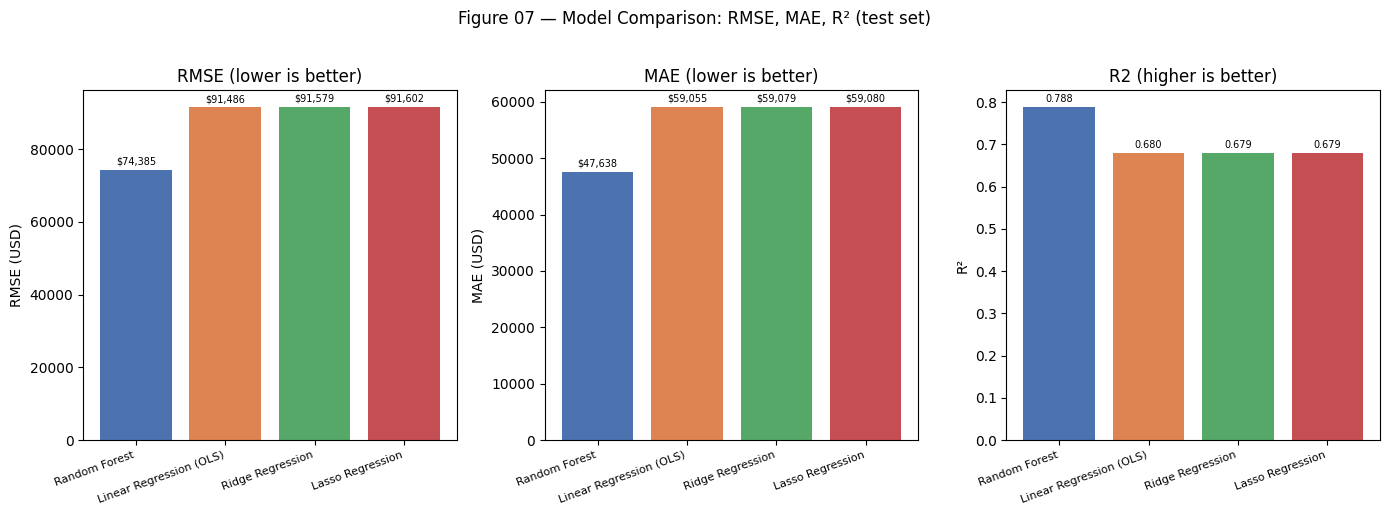

Saved: fig07_model_comparison.png


In [15]:
comparison = pd.DataFrame([
    {'Model': r['label'], 'RMSE': r['RMSE'], 'MAE': r['MAE'], 'R2': r['R2']}
    for r in results.values()
]).sort_values('RMSE')

print('=== Model Comparison (test set) ===')
print()
print(comparison.to_string(index=False, float_format=lambda x: f'{x:,.0f}' if x > 1 else f'{x:.4f}'))

# Figure 07: Model comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Figure 07 — Model Comparison: RMSE, MAE, R² (test set)',
    fontsize=12, y=1.02
)

metrics = [('RMSE', 'RMSE (USD)', True), ('MAE', 'MAE (USD)', True), ('R2', 'R²', False)]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (metric, ylabel, lower_is_better) in zip(axes, metrics):
    vals   = comparison[metric].values
    labels = comparison['Model'].values
    bars   = ax.bar(range(len(labels)), vals, color=colors[:len(labels)])
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric} ({"lower" if lower_is_better else "higher"} is better)')
    for bar, val in zip(bars, vals):
        label = f'${val:,.0f}' if lower_is_better else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                label, ha='center', va='bottom', fontsize=7)

plt.tight_layout()
fig.savefig(REPORTS_DIR / 'fig07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig07_model_comparison.png')

---
## Section 9 — Feature Importance (Random Forest)

Random Forest assigns an **importance score** to each feature based on how much including that feature in splits reduces prediction error, averaged across all trees. Higher importance means the model leaned on that feature more heavily.

This is not the same as a regression coefficient — it does not tell you the direction of the effect (positive or negative). It tells you how much predictive signal the model found in that feature. We use it to validate that the model is relying on sensible inputs, not spurious ones.

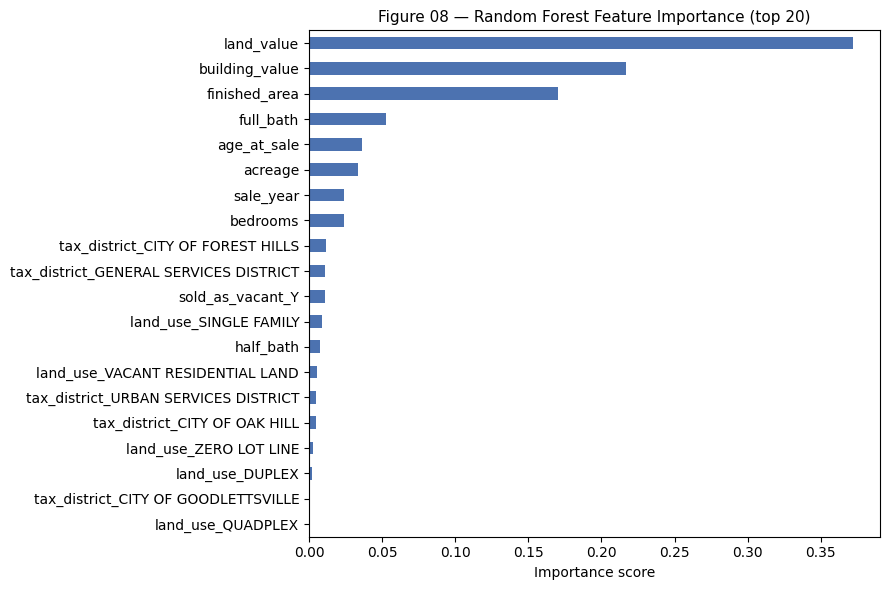

Saved: fig08_feature_importance.png


In [16]:
importances = pd.Series(
    results['RF']['model'].feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

top_n = 20
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
top_features.sort_values().plot.barh(ax=ax, color='#4C72B0')
ax.set_title(
    f'Figure 08 — Random Forest Feature Importance (top {top_n})',
    fontsize=11
)
ax.set_xlabel('Importance score')
ax.set_ylabel('')
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'fig08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig08_feature_importance.png')

---
## Section 10 — Residual Analysis

We use the best-performing model's residuals to identify systematic mis-valuation.

A **residual** is the difference between the actual sale price and the model's prediction:
```
residual = actual_price - predicted_price
```

- **Positive residual:** the property sold for more than expected — potentially overvalued.
- **Negative residual:** the property sold for less than expected — potentially undervalued.

If residuals are random, the model is working well and the price differences are just noise. If residuals cluster by tax district or property type, it means the model is systematically wrong in those groups — which is evidence that something about that group is not captured by the features, and that systematic difference may reflect genuine mis-valuation.

We use the **best-performing model** from Section 8. We extract residuals on the test set only — using training set residuals would be misleading because the model has already overfit to those records.

In [17]:
# Identify best model by lowest RMSE
best_key  = comparison.iloc[0]['Model']
best_label = best_key

# Map display label back to results dict key
label_to_key = {v['label']: k for k, v in results.items()}
best_key_dict = label_to_key[best_key]
best_result   = results[best_key_dict]

print(f'Best model : {best_label}')
print(f'RMSE       : ${best_result["RMSE"]:,.0f}')
print(f'R²         : {best_result["R2"]:.4f}')

Best model : Random Forest
RMSE       : $74,385
R²         : 0.7884


In [18]:
# Build residual dataframe — join back to original data for group labels
y_pred_best = best_result['y_pred']

resid_df = pd.DataFrame({
    'parcel_id' : id_test.values,
    'actual'    : y_test.values,
    'predicted' : y_pred_best,
    'residual'  : y_test.values - y_pred_best
})

# Join back to original df to get tax_district and land_use labels
resid_df = resid_df.merge(
    df[['parcel_id', 'tax_district', 'land_use', 'sale_year']],
    on='parcel_id',
    how='left'
)

# Standardise residuals (z-score) for comparability across groups
resid_std  = resid_df['residual'].std()
resid_mean = resid_df['residual'].mean()
resid_df['residual_z'] = (resid_df['residual'] - resid_mean) / resid_std

print(f'Mean residual   : ${resid_mean:,.0f}  (should be near zero if model is unbiased)')
print(f'Std of residuals: ${resid_std:,.0f}')
print()
print('Residual distribution:')
print(resid_df['residual'].describe().apply(lambda x: f'${x:,.0f}'))

Mean residual   : $-3,236  (should be near zero if model is unbiased)
Std of residuals: $78,664

Residual distribution:
count       $5,926
mean       $-3,236
std        $78,664
min      $-587,593
25%       $-37,746
50%        $-3,925
75%        $28,612
max       $636,754
Name: residual, dtype: str


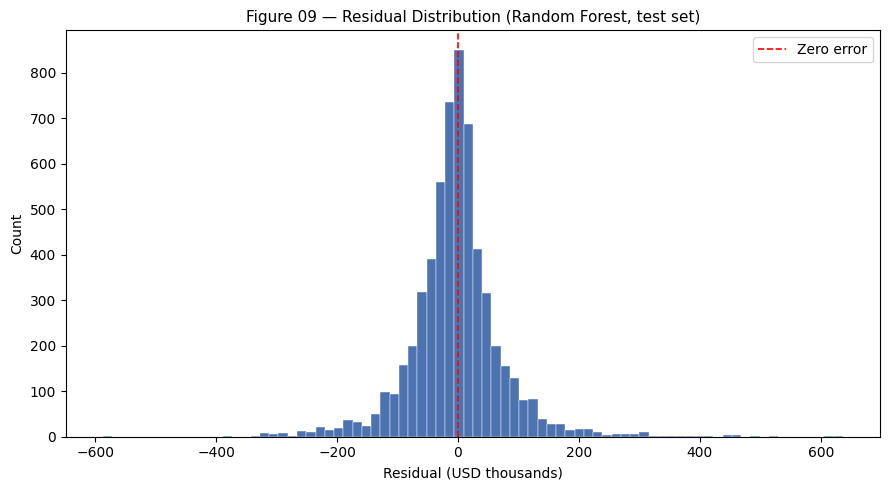

Saved: fig09_residual_distribution.png


In [19]:
# Figure 09: Residual distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(resid_df['residual'] / 1000, bins=80, color='#4C72B0', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero error')
ax.set_xlabel('Residual (USD thousands)')
ax.set_ylabel('Count')
ax.set_title(
    f'Figure 09 — Residual Distribution ({best_label}, test set)',
    fontsize=11
)
ax.legend()
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'fig09_residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig09_residual_distribution.png')

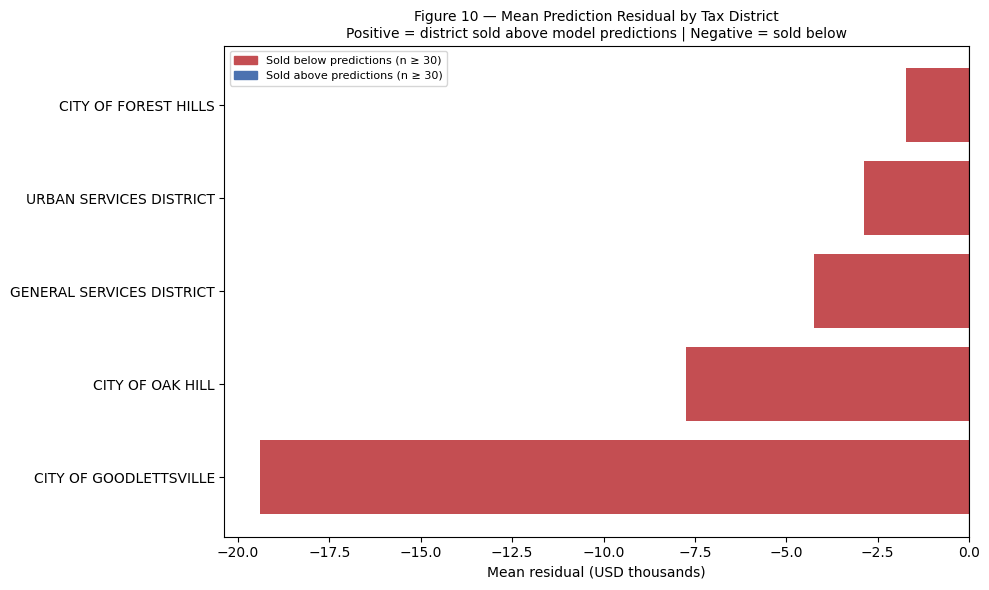

Saved: fig10_residual_by_district.png


In [20]:
# Figure 10: Mean residual by tax district
# A district with a consistently positive mean residual sold above model predictions
# — suggesting the model undervalues that district.
# A district with a consistently negative mean residual sold below predictions
# — suggesting the model overvalues that district.

district_resid = (
    resid_df
    .groupby('tax_district')['residual']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'mean_residual', 'count': 'n'})
    .query('n >= 30')   # Require at least 30 test records per district for stability
    .sort_values('mean_residual')
    .reset_index()
)

colors_dist = ['#C44E52' if v < 0 else '#4C72B0' for v in district_resid['mean_residual']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(district_resid['tax_district'], district_resid['mean_residual'] / 1000,
        color=colors_dist)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean residual (USD thousands)')
ax.set_title(
    'Figure 10 — Mean Prediction Residual by Tax District\n'
    'Positive = district sold above model predictions | Negative = sold below',
    fontsize=10
)
red_patch  = mpatches.Patch(color='#C44E52', label='Sold below predictions (n ≥ 30)')
blue_patch = mpatches.Patch(color='#4C72B0', label='Sold above predictions (n ≥ 30)')
ax.legend(handles=[red_patch, blue_patch], fontsize=8)
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'fig10_residual_by_district.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig10_residual_by_district.png')

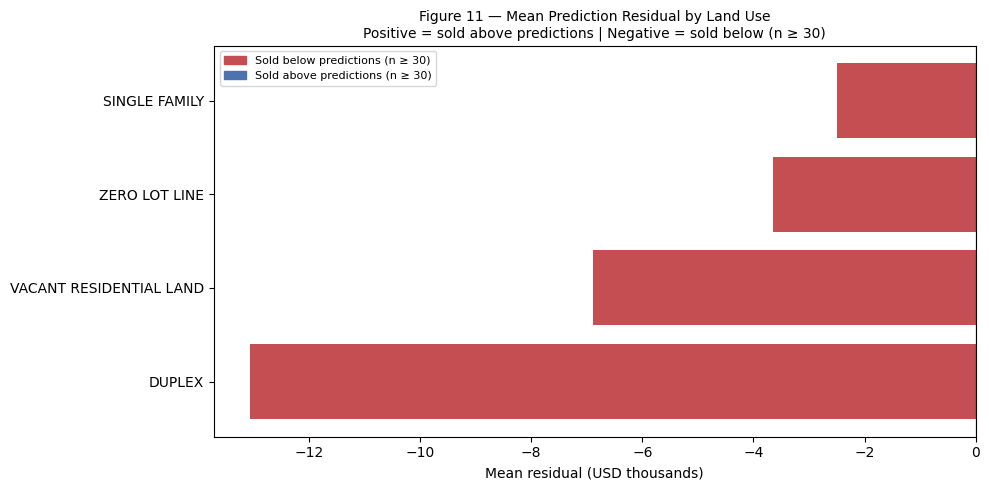

Saved: fig11_residual_by_land_use.png


In [21]:
# Figure 11: Mean residual by land use (top categories by volume)
land_use_resid = (
    resid_df
    .groupby('land_use')['residual']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'mean_residual', 'count': 'n'})
    .query('n >= 30')
    .sort_values('mean_residual')
    .reset_index()
)

colors_lu = ['#C44E52' if v < 0 else '#4C72B0' for v in land_use_resid['mean_residual']]

fig, ax = plt.subplots(figsize=(10, max(5, len(land_use_resid) * 0.4)))
ax.barh(land_use_resid['land_use'], land_use_resid['mean_residual'] / 1000,
        color=colors_lu)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean residual (USD thousands)')
ax.set_title(
    'Figure 11 — Mean Prediction Residual by Land Use\n'
    'Positive = sold above predictions | Negative = sold below (n ≥ 30)',
    fontsize=10
)
ax.legend(handles=[red_patch, blue_patch], fontsize=8)
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'fig11_residual_by_land_use.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig11_residual_by_land_use.png')

In [22]:
# Flag the most extreme residuals for review
# Properties with |z-score| > 3 are outliers in residual space —
# the model's prediction was more than 3 standard deviations off.
# These are the best candidates for genuine mis-valuation.

threshold = 3.0
extreme = resid_df[resid_df['residual_z'].abs() > threshold].copy()
extreme['direction'] = extreme['residual_z'].apply(
    lambda z: 'SOLD ABOVE (overvalued?)' if z > 0 else 'SOLD BELOW (undervalued?)'
)

print(f'Records with |residual z-score| > {threshold}: {len(extreme)}')
print(f'As share of test set: {len(extreme)/len(resid_df):.1%}')
print()
print('Breakdown by direction:')
print(extreme['direction'].value_counts())
print()
print('Breakdown by tax district:')
print(extreme.groupby(['tax_district', 'direction']).size().reset_index(name='count').to_string(index=False))

Records with |residual z-score| > 3.0: 111
As share of test set: 1.9%

Breakdown by direction:
direction
SOLD ABOVE (overvalued?)     61
SOLD BELOW (undervalued?)    50
Name: count, dtype: int64

Breakdown by tax district:
             tax_district                 direction  count
      CITY OF BELLE MEADE  SOLD ABOVE (overvalued?)      1
      CITY OF BELLE MEADE SOLD BELOW (undervalued?)      1
     CITY OF FOREST HILLS  SOLD ABOVE (overvalued?)      1
         CITY OF OAK HILL  SOLD ABOVE (overvalued?)      3
GENERAL SERVICES DISTRICT  SOLD ABOVE (overvalued?)      9
  URBAN SERVICES DISTRICT  SOLD ABOVE (overvalued?)     47
  URBAN SERVICES DISTRICT SOLD BELOW (undervalued?)     49


In [23]:
# Save residual data for reference and potential use in Notebook 04
resid_output = resid_df[['parcel_id', 'tax_district', 'land_use', 'sale_year',
                          'actual', 'predicted', 'residual', 'residual_z']]

out_path = PROJECT_ROOT / 'data' / 'processed' / 'residuals_test_set.csv'
resid_output.to_csv(out_path, index=False)
print(f'Saved residuals to: {out_path}')
print(f'Rows: {len(resid_output):,}')

Saved residuals to: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Github refurb/nashville analytics/data/processed/residuals_test_set.csv
Rows: 5,926


---
## Section 11 — Predicted vs Actual Plot

A predicted vs actual scatter plot is a standard model diagnostic. On a perfect model, every point lies on the 45-degree line (predicted = actual). The spread around that line shows where and how much the model errs. Systematic curves or fans in the plot reveal non-linearity or heteroscedasticity (error variance that changes with price level) that the model has not captured.

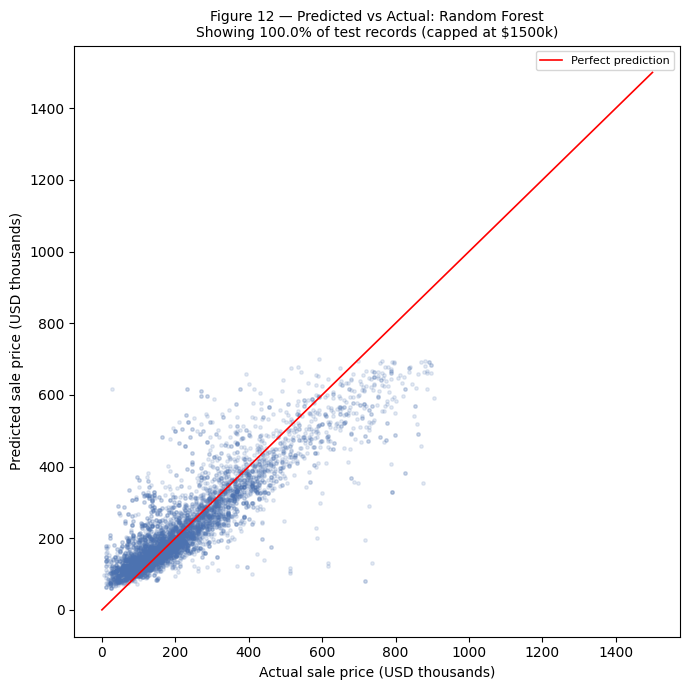

Saved: fig12_predicted_vs_actual.png


In [24]:
cap = 1_500_000   # Cap axis at $1.5M for readability — extreme outliers compress the plot

plot_df = resid_df[(resid_df['actual'] <= cap) & (resid_df['predicted'] <= cap)].copy()
pct_shown = len(plot_df) / len(resid_df)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_df['actual'] / 1000, plot_df['predicted'] / 1000,
           alpha=0.15, s=6, color='#4C72B0')
max_val = cap / 1000
ax.plot([0, max_val], [0, max_val], color='red', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual sale price (USD thousands)')
ax.set_ylabel('Predicted sale price (USD thousands)')
ax.set_title(
    f'Figure 12 — Predicted vs Actual: {best_label}\n'
    f'Showing {pct_shown:.1%} of test records (capped at ${cap/1000:.0f}k)',
    fontsize=10
)
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(REPORTS_DIR / 'fig12_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig12_predicted_vs_actual.png')

---
## Section 12 — Summary of Findings
---

**Best model:** Random Forest

**Test set performance:**
- RMSE: $74385
- MAE: $47638
- R²: 78%

**Model comparison interpretation:**  
Random Forest outperformed the regression suite substantially, suggesting features interact with each other in ways a straight-line model cannot capture. The three regression models performed almost identically to each other — Ridge and Lasso showed no meaningful improvement over plain OLS — which confirms the regression models were not failing due to correlated features. The relationships themselves are non-linear.

**Feature importance findings:**  
`land_value` was the dominant feature at roughly 0.37, followed by `building_value` and `finished_area` with the others contributing little individually. Domainwise, valuation of land and building are strong signals of market value so this is a positive outlook for our model

**Residual findings by district:**  
No district showed properties selling above model predictions — all mean residuals were negative, indicating a systematic upward bias in predictions. This is likely driven by a subset of very high-value properties in the training set pulling predictions upward across the board. The model is most reliable for properties below $400k and becomes unreliable above $500k, where prediction errors grow significantly.

**Residual findings by land use:**  
Same as with the residual findings by district. A bias was present which skewed predictions and thus there were no sales above model predictions

**Extreme mis-valuation cases:**  
111 records had |z| > 3 and these were concentrated around the Urban services district

**Scope caveat:**  
All findings are based on the ~41% of clean records with complete assessment-side data. The remaining 59% of the dataset was excluded because imputing assessment values would mean modelling imputed data rather than real property characteristics.